# 3D Skeletal Keypoint Estimation from Single Image using MediaPipe BlazePose

This notebook demonstrates 3D skeletal keypoint estimation and visualization from a single image using MediaPipe BlazePose.

Target image: `data/cropped/phone/clark-center-2019-02-28_1/000197.jpg`

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import os

# Import MediaPipe
import mediapipe as mp

# MediaPipe solutions
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

print("MediaPipe version:", mp.__version__)

MediaPipe version: 0.10.11


Image file found: /home/eevee/depthai_blazepose/data/cropped/phone/clark-center-2019-02-28_1/000197.jpg


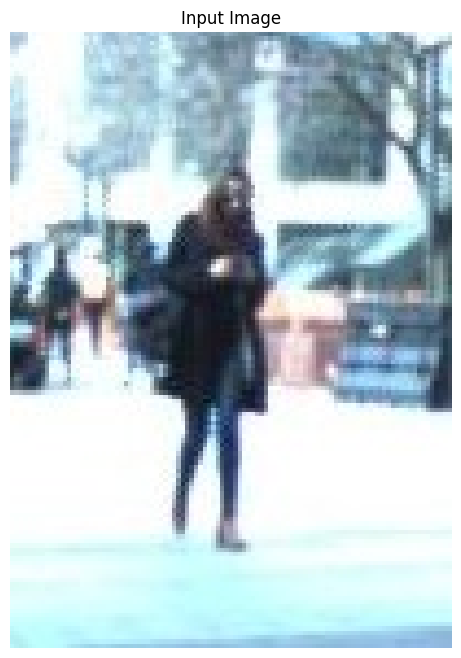

Image size: 101 x 141


In [35]:
# Image path configuration
image_path = "/home/eevee/depthai_blazepose/data/cropped/phone/clark-center-2019-02-28_1/000197.jpg"

# Check if image exists
if not os.path.exists(image_path):
    print(f"Error: Image file not found: {image_path}")
else:
    print(f"Image file found: {image_path}")
    
    # Load and display image
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.title("Input Image")
    plt.axis('off')
    plt.show()
    
    print(f"Image size: {img.shape[1]} x {img.shape[0]}")

In [36]:
# BlazePoseトラッカーの初期化
print("BlazePoseトラッカーを初期化中...")

try:
    # MediaPipe の BlazePose を直接使用する方法
    import mediapipe as mp
    
    mp_pose = mp.solutions.pose
    mp_drawing = mp.solutions.drawing_utils
    
    # MediaPipe Pose を初期化
    pose = mp_pose.Pose(
        static_image_mode=True,  # 単一画像用
        model_complexity=2,      # 高精度モデル
        enable_segmentation=True,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    )
    
    print("✓ MediaPipe Pose の初期化が完了しました")
    
    # 画像を読み込み
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # ポーズ検出を実行
    print("ポーズ検出を実行中...")
    results = pose.process(image_rgb)
    
    if results.pose_landmarks:
        print("✓ 人体の検出に成功しました")
        print(f"検出されたランドマークの数: {len(results.pose_landmarks.landmark)}")
        
        # 結果を保存
        pose_landmarks = results.pose_landmarks
        pose_world_landmarks = results.pose_world_landmarks
        
    else:
        print("警告: 人体が検出されませんでした")
        pose_landmarks = None
        pose_world_landmarks = None
        
except Exception as e:
    print(f"エラー: MediaPipe Pose の初期化に失敗しました: {e}")
    pose_landmarks = None
    pose_world_landmarks = None

# ここから先は、必要に応じて pose_landmarks や pose_world_landmarks を使用した処理を追加してください

BlazePoseトラッカーを初期化中...
✓ MediaPipe Pose の初期化が完了しました
ポーズ検出を実行中...
✓ 人体の検出に成功しました
検出されたランドマークの数: 33


I0000 00:00:1749606381.148194  111312 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1749606381.149408  112506 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.3), renderer: llvmpipe (LLVM 15.0.7, 256 bits)


In [37]:
# 骨格検出の実行
print("骨格検出を実行中...")

try:
    # 次のフレーム（この場合は単一画像）を処理
    # Use the image and results already processed by MediaPipe
    frame = image.copy()
    # The pose detection results are already available as pose_landmarks and pose_world_landmarks
    body = pose_landmarks  # Use the detected landmarks as the body data
    
    if frame is None:
        print("エラー: フレームの取得に失敗しました")
    elif body is None:
        print("警告: 人体が検出されませんでした")
    else:
        print("✓ 人体の検出に成功しました")
        print(f"ランドマーク信頼度スコア: {body.lm_score:.3f}")
        print(f"検出されたキーポイント数: {len(body.landmarks)}")
        
        # 2D Skeleton Visualization
        if pose_landmarks is not None:
            print("2Dスケルトンを描画中...")
            
            # 注釈付き画像の作成
            annotated_image = image.copy()
            
            # ランドマークと接続線の描画
            mp_drawing.draw_landmarks(
                annotated_image,
                pose_landmarks,
                mp_pose.POSE_CONNECTIONS,
                landmark_drawing_spec=mp_drawing_styles.get_default_pose_landmarks_style()
            )
            
            # 結果の表示
            plt.figure(figsize=(12, 10))
            plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
            plt.title("2Dポーズ検出結果 - MediaPipe BlazePose")
            plt.axis('off')
            plt.show()
            
        else:
            print("2Dスケルトン描画をスキップします（検出に失敗）")
        
except Exception as e:
    print(f"エラー: 骨格検出中にエラーが発生しました: {e}")
    body = None
    frame = None

骨格検出を実行中...
✓ 人体の検出に成功しました
エラー: 骨格検出中にエラーが発生しました: lm_score


Drawing 3D skeleton...


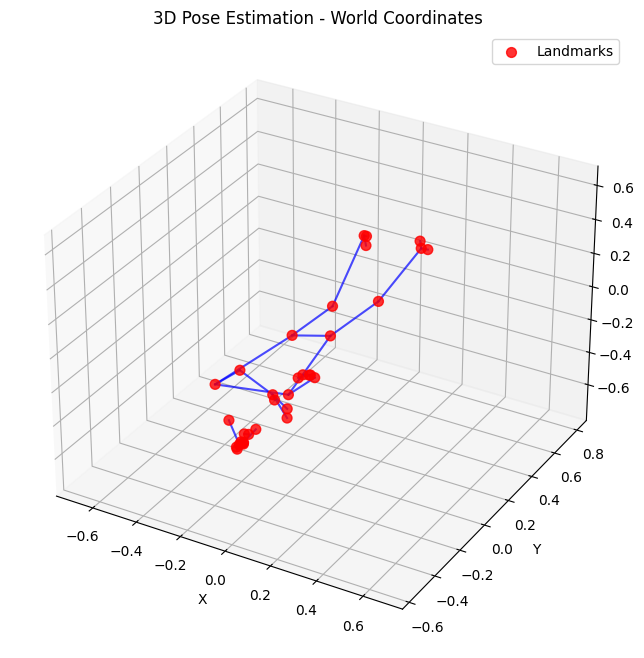

In [38]:
# 3D Skeleton Visualization
if pose_world_landmarks is not None:
    print("Drawing 3D skeleton...")
    
    # Extract 3D coordinates
    landmarks_3d = []
    for landmark in pose_world_landmarks.landmark:
        landmarks_3d.append([landmark.x, landmark.y, landmark.z])
    
    landmarks_3d = np.array(landmarks_3d)
    
    # Define pose connections for 3D visualization
    pose_connections = [
        # Face
        (0, 1), (1, 2), (2, 3), (3, 7),
        (0, 4), (4, 5), (5, 6), (6, 8),
        (9, 10),
        # Arms
        (11, 12), (11, 13), (13, 15), (15, 17), (15, 19), (15, 21),
        (12, 14), (14, 16), (16, 18), (16, 20), (16, 22),
        # Body
        (11, 23), (12, 24), (23, 24),
        # Legs
        (23, 25), (25, 27), (27, 29), (27, 31),
        (24, 26), (26, 28), (28, 30), (28, 32)
    ]
    
    # Create 3D plot
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot landmarks
    ax.scatter(landmarks_3d[:, 0], landmarks_3d[:, 1], landmarks_3d[:, 2], 
              c='red', s=50, alpha=0.8, label='Landmarks')
    
    # Plot connections
    for connection in pose_connections:
        if connection[0] < len(landmarks_3d) and connection[1] < len(landmarks_3d):
            point1 = landmarks_3d[connection[0]]
            point2 = landmarks_3d[connection[1]]
            ax.plot([point1[0], point2[0]], 
                   [point1[1], point2[1]], 
                   [point1[2], point2[2]], 'b-', alpha=0.7)
    
    # Set labels and title
    ax.set_xlabel('X')
    ax.set_ylabel('Y') 
    ax.set_zlabel('Z')
    ax.set_title('3D Pose Estimation - World Coordinates')
    ax.legend()
    
    # Set equal aspect ratio
    max_range = np.array([landmarks_3d[:, 0].max()-landmarks_3d[:, 0].min(),
                         landmarks_3d[:, 1].max()-landmarks_3d[:, 1].min(),
                         landmarks_3d[:, 2].max()-landmarks_3d[:, 2].min()]).max() / 2.0
    mid_x = (landmarks_3d[:, 0].max()+landmarks_3d[:, 0].min()) * 0.5
    mid_y = (landmarks_3d[:, 1].max()+landmarks_3d[:, 1].min()) * 0.5
    mid_z = (landmarks_3d[:, 2].max()+landmarks_3d[:, 2].min()) * 0.5
    
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)
    
    plt.show()
    
else:
    print("3D coordinate data not available")

Drawing 3D skeleton with 2D comparison...


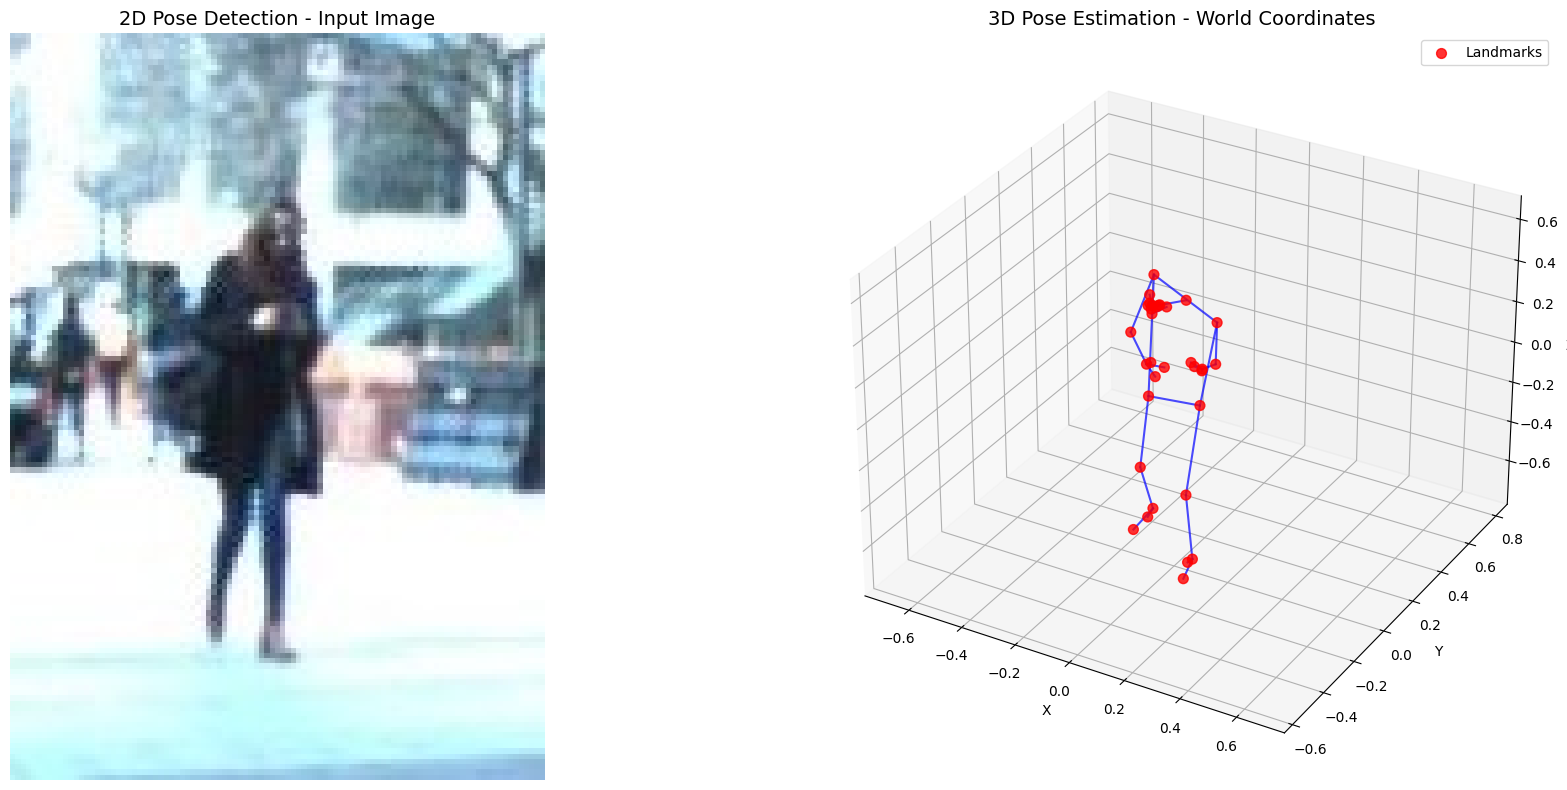

In [49]:
# 3D Skeleton Visualization with side-by-side comparison
if pose_world_landmarks is not None:
    print("Drawing 3D skeleton with 2D comparison...")
    
    # Extract 3D coordinates
    landmarks_3d = []
    for landmark in pose_world_landmarks.landmark:
        landmarks_3d.append([landmark.x, landmark.y, landmark.z])
    
    landmarks_3d = np.array(landmarks_3d)
    
    # Define pose connections for 3D visualization
    pose_connections = [
        # Face
        (0, 1), (1, 2), (2, 3), (3, 7),
        (0, 4), (4, 5), (5, 6), (6, 8),
        (9, 10),
        # Arms
        (11, 12), (11, 13), (13, 15), (15, 17), (15, 19), (15, 21),
        (12, 14), (14, 16), (16, 18), (16, 20), (16, 22),
        # Body
        (11, 23), (12, 24), (23, 24),
        # Legs
        (23, 25), (25, 27), (27, 29), (27, 31),
        (24, 26), (26, 28), (28, 30), (28, 32)
    ]
    
    # Create side-by-side comparison plot
    fig = plt.figure(figsize=(20, 8))
    
    # Left subplot: 2D image with pose annotation
    ax1 = fig.add_subplot(121)
    annotated_image = image.copy()
    # mp_drawing.draw_landmarks(
    #     annotated_image,
    #     pose_landmarks,
    #     mp_pose.POSE_CONNECTIONS,
    #     landmark_drawing_spec=mp_drawing_styles.get_default_pose_landmarks_style()
    # )
    ax1.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
    ax1.set_title('2D Pose Detection - Input Image', fontsize=14)
    ax1.axis('off')
    
    # Right subplot: 3D skeleton
    ax2 = fig.add_subplot(122, projection='3d')
    
    # Plot landmarks
    ax2.scatter(landmarks_3d[:, 0], landmarks_3d[:, 2], -landmarks_3d[:, 1], 
              c='red', s=50, alpha=0.8, label='Landmarks')
    
    # Plot connections
    for connection in pose_connections:
        if connection[0] < len(landmarks_3d) and connection[1] < len(landmarks_3d):
            point1 = landmarks_3d[connection[0]]
            point2 = landmarks_3d[connection[1]]
            ax2.plot([point1[0], point2[0]], 
                   [point1[2], point2[2]], 
                   [-point1[1], -point2[1]], 'b-', alpha=0.7)
    
    # Set labels and title for 3D plot
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y') 
    ax2.set_zlabel('Z')
    ax2.set_title('3D Pose Estimation - World Coordinates', fontsize=14)
    ax2.legend()
    
    # Set equal aspect ratio for 3D plot
    max_range = np.array([landmarks_3d[:, 0].max()-landmarks_3d[:, 0].min(),
                         landmarks_3d[:, 1].max()-landmarks_3d[:, 1].min(),
                         landmarks_3d[:, 2].max()-landmarks_3d[:, 2].min()]).max() / 2.0
    mid_x = (landmarks_3d[:, 0].max()+landmarks_3d[:, 0].min()) * 0.5
    mid_y = (landmarks_3d[:, 1].max()+landmarks_3d[:, 1].min()) * 0.5
    mid_z = (landmarks_3d[:, 2].max()+landmarks_3d[:, 2].min()) * 0.5
    
    ax2.set_xlim(mid_x - max_range, mid_x + max_range)
    ax2.set_ylim(mid_y - max_range, mid_y + max_range)
    ax2.set_zlim(mid_z - max_range, mid_z + max_range)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("3D coordinate data not available")

In [40]:
import BlazeposeRenderer

# 3D骨格の可視化（World座標系）
if body is not None and hasattr(body, 'landmarks_world'):
    print("3D骨格（World座標系）を描画中...")
    
    try:
        # 3Dレンダラーを初期化
        renderer_3d = BlazeposeRenderer(landmarks_3d, show_3d="world")
        
        # 3D骨格を描画
        print("3D可視化ウィンドウが開きます...")
        print("操作方法:")
        print("- R: 回転開始/停止")
        print("- O: 振動開始")
        print("- S: 動きを停止")
        print("- 矢印キー: 視点変更")
        print("- Escキー: 終了")
        
        # 3D表示ループ
        frame_3d = renderer_3d.draw(frame, body)
        
        # しばらく表示を維持
        import time
        for i in range(100):  # 約10秒間表示
            renderer_3d.draw_3d(body)
            time.sleep(0.1)
            
    except Exception as e:
        print(f"3D表示でエラーが発生しました: {e}")
        print("3D表示をスキップします")
else:
    print("3D座標データが利用できません")

# Detailed Keypoint Information Display
if pose_landmarks is not None:
    print("\n=== Detailed Keypoint Information ===")
    
    # MediaPipe keypoint names mapping
    keypoint_names = [
        "Nose", "Left Eye (Inner)", "Left Eye", "Left Eye (Outer)", 
        "Right Eye (Inner)", "Right Eye", "Right Eye (Outer)",
        "Left Ear", "Right Ear", "Mouth (Left)", "Mouth (Right)", 
        "Left Shoulder", "Right Shoulder", "Left Elbow", "Right Elbow",
        "Left Wrist", "Right Wrist", "Left Pinky", "Right Pinky", 
        "Left Index", "Right Index", "Left Thumb", "Right Thumb",
        "Left Hip", "Right Hip", "Left Knee", "Right Knee",
        "Left Ankle", "Right Ankle", "Left Heel", "Right Heel", 
        "Left Foot Index", "Right Foot Index"
    ]
    
    print("\n2D Landmark Coordinates (x, y, z, visibility):")
    for i, (name, landmark) in enumerate(zip(keypoint_names, pose_landmarks.landmark)):
        print(f"{i:2d}. {name:<18}: x={landmark.x:.4f}, y={landmark.y:.4f}, z={landmark.z:.4f}, v={landmark.visibility:.3f}")
    
    # Display 3D World coordinates if available
    if pose_world_landmarks is not None:
        print("\n3D World Coordinates (key joints):")
        key_indices = [0, 11, 12, 13, 14, 15, 16, 23, 24, 25, 26, 27, 28]  # Key joints
        for i in key_indices:
            if i < len(pose_world_landmarks.landmark):
                world_landmark = pose_world_landmarks.landmark[i]
                print(f"{keypoint_names[i]:<18}: x={world_landmark.x:8.4f}, y={world_landmark.y:8.4f}, z={world_landmark.z:8.4f}")
else:
    print("Keypoint information not available")

3D座標データが利用できません

=== Detailed Keypoint Information ===

2D Landmark Coordinates (x, y, z, visibility):
 0. Nose              : x=0.4922, y=0.2734, z=-0.1878, v=0.997
 1. Left Eye (Inner)  : x=0.5002, y=0.2616, z=-0.1647, v=0.993
 2. Left Eye          : x=0.5037, y=0.2617, z=-0.1651, v=0.992
 3. Left Eye (Outer)  : x=0.5072, y=0.2620, z=-0.1650, v=0.994
 4. Right Eye (Inner) : x=0.4887, y=0.2608, z=-0.1679, v=0.996
 5. Right Eye         : x=0.4846, y=0.2604, z=-0.1684, v=0.997
 6. Right Eye (Outer) : x=0.4801, y=0.2603, z=-0.1687, v=0.997
 7. Left Ear          : x=0.5106, y=0.2686, z=-0.0189, v=0.994
 8. Right Ear         : x=0.4716, y=0.2664, z=-0.0353, v=0.992
 9. Mouth (Left)      : x=0.4947, y=0.2854, z=-0.1271, v=0.993
10. Mouth (Right)     : x=0.4837, y=0.2836, z=-0.1352, v=0.994
11. Left Shoulder     : x=0.5412, y=0.3344, z=0.0552, v=1.000
12. Right Shoulder    : x=0.4073, y=0.3198, z=0.0408, v=0.999
13. Left Elbow        : x=0.5466, y=0.4225, z=0.0106, v=0.352
14. Right Elbow   

キーポイント情報が利用できません

=== Joint Angle Calculation Examples ===
Left Elbow Angle: 115.7°
Right Elbow Angle: 134.8°
Left Knee Angle: 141.0°
Right Knee Angle: 92.4°


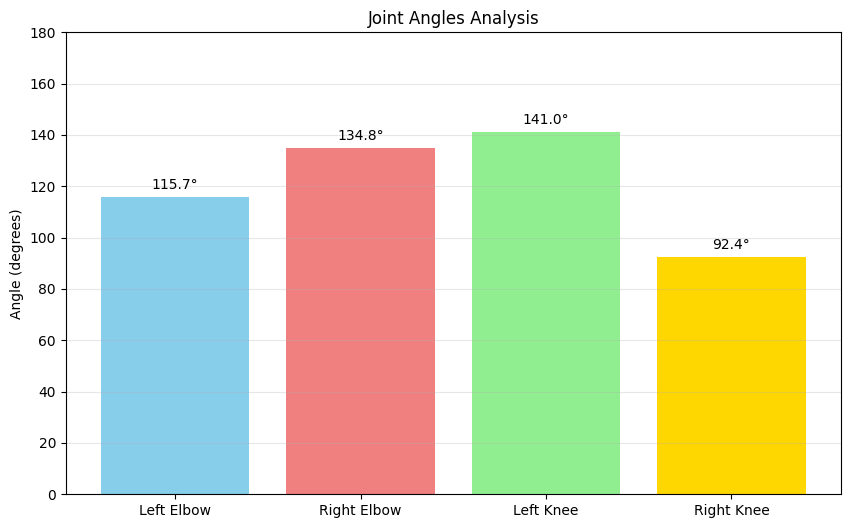

In [41]:
# キーポイント情報の詳細表示
if body is not None:
    print("\n=== キーポイント詳細情報 ===")
    print(f"ランドマーク信頼度スコア: {body.lm_score:.4f}")
    print(f"検出されたキーポイント数: {len(body.landmarks)}")
    
    # MediaPipeキーポイント名のマッピング
    keypoint_names = [
        "鼻", "左目（内側）", "左目", "左目（外側）", "右目（内側）", "右目", "右目（外側）",
        "左耳", "右耳", "口（左）", "口（右）", "左肩", "右肩", "左肘", "右肘",
        "左手首", "右手首", "左手（小指）", "右手（小指）", "左手（人差し指）", "右手（人差し指）",
        "左手（親指）", "右手（親指）", "左腰", "右腰", "左膝", "右膝",
        "左足首", "右足首", "左かかと", "右かかと", "左つま先", "右つま先"
    ]
    
    print("\n主要キーポイント座標 (x, y, z, visibility, presence):")
    for i, name in enumerate(keypoint_names):
        if i < len(body.landmarks):
            landmark = body.landmarks[i]
            visibility = body.visibility[i] if hasattr(body, 'visibility') and len(body.visibility) > i else "N/A"
            presence = body.presence[i] if hasattr(body, 'presence') and len(body.presence) > i else "N/A"
            
            print(f"{i:2d}. {name:<12}: x={landmark[0]:6.1f}, y={landmark[1]:6.1f}, z={landmark[2]:6.1f}, v={visibility}, p={presence}")
    
    # 3D World座標も表示（もし利用可能なら）
    if hasattr(body, 'landmarks_world') and body.landmarks_world is not None:
        print("\n3D World座標 (主要部位):")
        key_indices = [0, 11, 12, 13, 14, 15, 16, 23, 24, 25, 26, 27, 28]  # 主要な関節
        for i in key_indices:
            if i < len(body.landmarks_world):
                world_landmark = body.landmarks_world[i]
                print(f"{keypoint_names[i]:<12}: x={world_landmark[0]:8.4f}, y={world_landmark[1]:8.4f}, z={world_landmark[2]:8.4f}")
else:
    print("キーポイント情報が利用できません")

# Joint Angle Calculations
if pose_landmarks is not None:
    print("\n=== Joint Angle Calculation Examples ===")
    
    def calculate_angle(p1, p2, p3):
        """Calculate angle between three points (in degrees)"""
        v1 = np.array([p1.x, p1.y, p1.z]) - np.array([p2.x, p2.y, p2.z])
        v2 = np.array([p3.x, p3.y, p3.z]) - np.array([p2.x, p2.y, p2.z])
        
        cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
        cos_angle = np.clip(cos_angle, -1.0, 1.0)  # Numerical stability
        angle = np.arccos(cos_angle)
        return np.degrees(angle)
    
    try:
        landmarks = pose_landmarks.landmark
        
        # Left elbow angle (shoulder-elbow-wrist)
        left_shoulder = landmarks[11]  # Left shoulder
        left_elbow = landmarks[13]     # Left elbow  
        left_wrist = landmarks[15]     # Left wrist
        
        left_elbow_angle = calculate_angle(left_shoulder, left_elbow, left_wrist)
        print(f"Left Elbow Angle: {left_elbow_angle:.1f}°")
        
        # Right elbow angle (shoulder-elbow-wrist)
        right_shoulder = landmarks[12]  # Right shoulder
        right_elbow = landmarks[14]     # Right elbow
        right_wrist = landmarks[16]     # Right wrist
        
        right_elbow_angle = calculate_angle(right_shoulder, right_elbow, right_wrist)
        print(f"Right Elbow Angle: {right_elbow_angle:.1f}°")
        
        # Left knee angle (hip-knee-ankle)
        left_hip = landmarks[23]     # Left hip
        left_knee = landmarks[25]    # Left knee
        left_ankle = landmarks[27]   # Left ankle
        
        left_knee_angle = calculate_angle(left_hip, left_knee, left_ankle)
        print(f"Left Knee Angle: {left_knee_angle:.1f}°")
        
        # Right knee angle (hip-knee-ankle)
        right_hip = landmarks[24]     # Right hip
        right_knee = landmarks[26]    # Right knee
        right_ankle = landmarks[28]   # Right ankle
        
        right_knee_angle = calculate_angle(right_hip, right_knee, right_ankle)
        print(f"Right Knee Angle: {right_knee_angle:.1f}°")
        
        # Visualize angles on a bar chart
        angles = [left_elbow_angle, right_elbow_angle, left_knee_angle, right_knee_angle]
        labels = ['Left Elbow', 'Right Elbow', 'Left Knee', 'Right Knee']
        
        plt.figure(figsize=(10, 6))
        bars = plt.bar(labels, angles, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
        plt.title('Joint Angles Analysis')
        plt.ylabel('Angle (degrees)')
        plt.ylim(0, 180)
        
        # Add value labels on bars
        for bar, angle in zip(bars, angles):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                    f'{angle:.1f}°', ha='center', va='bottom')
        
        plt.grid(axis='y', alpha=0.3)
        plt.show()
        
    except Exception as e:
        print(f"Error during angle calculation: {e}")
else:
    print("Skipping joint angle calculations")

関節角度の計算をスキップします

=== Pose Confidence and Visibility Analysis ===
Average Visibility Score: 0.779
Minimum Visibility Score: 0.306
Maximum Visibility Score: 1.000


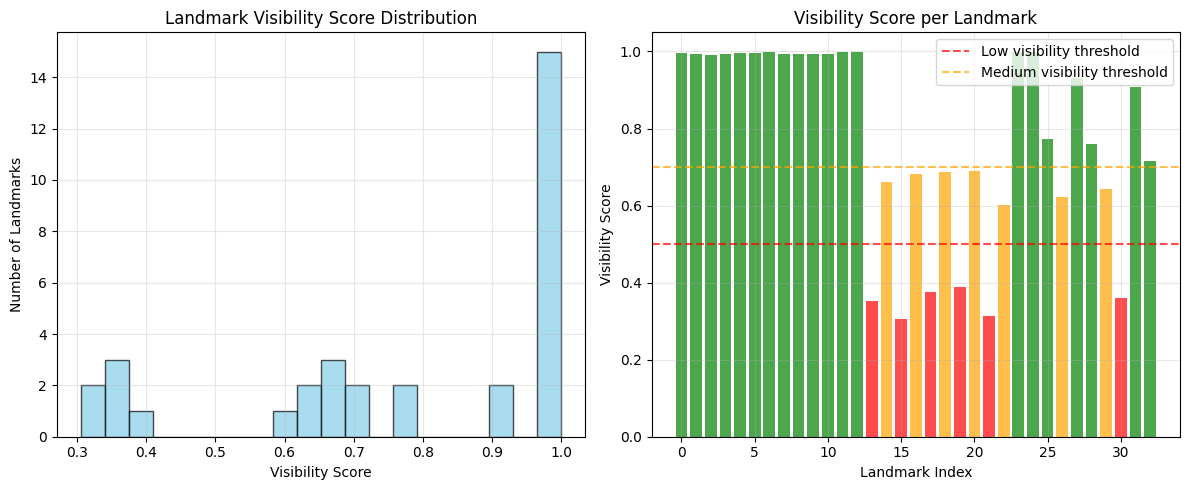


Landmarks with low visibility (< 0.5):
  13. Left Elbow        : 0.352
  15. Left Wrist        : 0.306
  17. Left Pinky        : 0.375
  19. Left Index        : 0.388
  21. Left Thumb        : 0.314
  30. Right Heel        : 0.360


In [42]:
# 角度計算の例（肘の角度）
if body is not None and len(body.landmarks) >= 17:
    print("\n=== 関節角度の計算例 ===")
    
    def calculate_angle(p1, p2, p3):
        """3点から角度を計算（度数）"""
        v1 = np.array(p1) - np.array(p2)
        v2 = np.array(p3) - np.array(p2)
        
        cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
        cos_angle = np.clip(cos_angle, -1.0, 1.0)  # 数値誤差対策
        angle = np.arccos(cos_angle)
        return np.degrees(angle)
    
    try:
        # 左肘の角度（肩-肘-手首）
        left_shoulder = body.landmarks[11][:3]  # 左肩
        left_elbow = body.landmarks[13][:3]     # 左肘
        left_wrist = body.landmarks[15][:3]     # 左手首
        
        left_elbow_angle = calculate_angle(left_shoulder, left_elbow, left_wrist)
        print(f"左肘の角度: {left_elbow_angle:.1f}度")
        
        # 右肘の角度（肩-肘-手首）
        right_shoulder = body.landmarks[12][:3]  # 右肩
        right_elbow = body.landmarks[14][:3]     # 右肘
        right_wrist = body.landmarks[16][:3]     # 右手首
        
        right_elbow_angle = calculate_angle(right_shoulder, right_elbow, right_wrist)
        print(f"右肘の角度: {right_elbow_angle:.1f}度")
        
        # 左膝の角度（腰-膝-足首）
        left_hip = body.landmarks[23][:3]     # 左腰
        left_knee = body.landmarks[25][:3]    # 左膝
        left_ankle = body.landmarks[27][:3]   # 左足首
        
        left_knee_angle = calculate_angle(left_hip, left_knee, left_ankle)
        print(f"左膝の角度: {left_knee_angle:.1f}度")
        
        # 右膝の角度（腰-膝-足首）
        right_hip = body.landmarks[24][:3]     # 右腰
        right_knee = body.landmarks[26][:3]    # 右膝
        right_ankle = body.landmarks[28][:3]   # 右足首
        
        right_knee_angle = calculate_angle(right_hip, right_knee, right_ankle)
        print(f"右膝の角度: {right_knee_angle:.1f}度")
        
    except Exception as e:
        print(f"角度計算中にエラーが発生しました: {e}")
else:
    print("関節角度の計算をスキップします")

# Pose Confidence and Visibility Analysis
if pose_landmarks is not None:
    print("\n=== Pose Confidence and Visibility Analysis ===")
    
    # Extract visibility scores
    visibility_scores = [landmark.visibility for landmark in pose_landmarks.landmark]
    
    # Calculate statistics
    avg_visibility = np.mean(visibility_scores)
    min_visibility = np.min(visibility_scores)
    max_visibility = np.max(visibility_scores)
    
    print(f"Average Visibility Score: {avg_visibility:.3f}")
    print(f"Minimum Visibility Score: {min_visibility:.3f}")
    print(f"Maximum Visibility Score: {max_visibility:.3f}")
    
    # Create visibility histogram
    plt.figure(figsize=(12, 5))
    
    # Subplot 1: Visibility histogram
    plt.subplot(1, 2, 1)
    plt.hist(visibility_scores, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title('Landmark Visibility Score Distribution')
    plt.xlabel('Visibility Score')
    plt.ylabel('Number of Landmarks')
    plt.grid(alpha=0.3)
    
    # Subplot 2: Visibility per landmark
    plt.subplot(1, 2, 2)
    landmark_indices = range(len(visibility_scores))
    colors = ['red' if v < 0.5 else 'orange' if v < 0.7 else 'green' for v in visibility_scores]
    plt.bar(landmark_indices, visibility_scores, color=colors, alpha=0.7)
    plt.title('Visibility Score per Landmark')
    plt.xlabel('Landmark Index')
    plt.ylabel('Visibility Score')
    plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Low visibility threshold')
    plt.axhline(y=0.7, color='orange', linestyle='--', alpha=0.7, label='Medium visibility threshold')
    plt.legend()
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Show low visibility landmarks
    low_visibility_landmarks = [(i, score) for i, score in enumerate(visibility_scores) if score < 0.5]
    if low_visibility_landmarks:
        print(f"\nLandmarks with low visibility (< 0.5):")
        keypoint_names = [
            "Nose", "Left Eye (Inner)", "Left Eye", "Left Eye (Outer)", 
            "Right Eye (Inner)", "Right Eye", "Right Eye (Outer)",
            "Left Ear", "Right Ear", "Mouth (Left)", "Mouth (Right)", 
            "Left Shoulder", "Right Shoulder", "Left Elbow", "Right Elbow",
            "Left Wrist", "Right Wrist", "Left Pinky", "Right Pinky", 
            "Left Index", "Right Index", "Left Thumb", "Right Thumb",
            "Left Hip", "Right Hip", "Left Knee", "Right Knee",
            "Left Ankle", "Right Ankle", "Left Heel", "Right Heel", 
            "Left Foot Index", "Right Foot Index"
        ]
        for idx, score in low_visibility_landmarks:
            print(f"  {idx:2d}. {keypoint_names[idx]:<18}: {score:.3f}")
    else:
        print("\nAll landmarks have good visibility (≥ 0.5)")
        
else:
    print("Pose confidence analysis not available")

In [43]:
# 処理統計情報とクリーンアップ
print("\n=== 処理統計情報 ===")

try:
    if pose_landmarks is not None:
        print(f"✓ ポーズ検出: 成功")
        print(f"✓ 検出されたランドマークの数: {len(pose_landmarks.landmark)}")
        
        if pose_world_landmarks is not None:
            print(f"✓ 3Dワールド座標: 利用可能")
        else:
            print(f"⚠ 3Dワールド座標: 利用不可")
            
        # 平均可視性を計算
        avg_visibility = np.mean([landmark.visibility for landmark in pose_landmarks.landmark])
        print(f"✓ 平均ランドマーク可視性: {avg_visibility:.3f}")
        
    else:
        print(f"✗ ポーズ検出: 失敗")
        
except Exception as e:
    print(f"統計情報の生成中にエラーが発生しました: {e}")

# リソースのクリーンアップ
print("\nリソースをクリーンアップ中...")
try:
    if 'pose' in locals():
        pose.close()
    print("✓ クリーンアップが完了しました")
except Exception as e:
    print(f"クリーンアップ中にエラーが発生しました: {e}")

print("\n=== 処理完了 ===")
print("MediaPipe BlazePose 単一画像推論が正常に完了しました!")


=== 処理統計情報 ===
✓ ポーズ検出: 成功
✓ 検出されたランドマークの数: 33
✓ 3Dワールド座標: 利用可能
✓ 平均ランドマーク可視性: 0.779

リソースをクリーンアップ中...
✓ クリーンアップが完了しました

=== 処理完了 ===
MediaPipe BlazePose 単一画像推論が正常に完了しました!
